In [1]:
# This Notebook is used to compute the gain of the SQUIDsim


In [6]:
import os

import matplotlib.pyplot as plt
# imports
import numpy as np

import readData as rddt


In [8]:
path = '/Users/laurent/data/TestPlan15-EGSE-boards'
fileLoopback = 'dump_20250410-154402.fits'
file1 = 'dump_20250410-154858.fits'
file2 = 'dump_20250410-160246.fits'

In [4]:
# Parameters for the spectral analysis. The unit seems to be per sqrt(Hz). I don't know why...
xlabel = r'Frequencies $(Hz)$'
#ylabel = r'Noise $\left(V_{rms} /\sqrt{Hz}\right)$'
ylabel = r'Error signal $\left(dBm / \sqrt{Hz} \right)$'
scaling = 'spectrum'
#scaling = 'density'
ymin, ymax = -100, -75
xmin, xmax = 1e5, 1e8

In [9]:
dumpref, _ = rddt.read_dump_from_fits(os.path.join(path, fileLoopback))
dump1, _ = rddt.read_dump_from_fits(os.path.join(path, file1))
dump2, _ = rddt.read_dump_from_fits(os.path.join(path, file2))

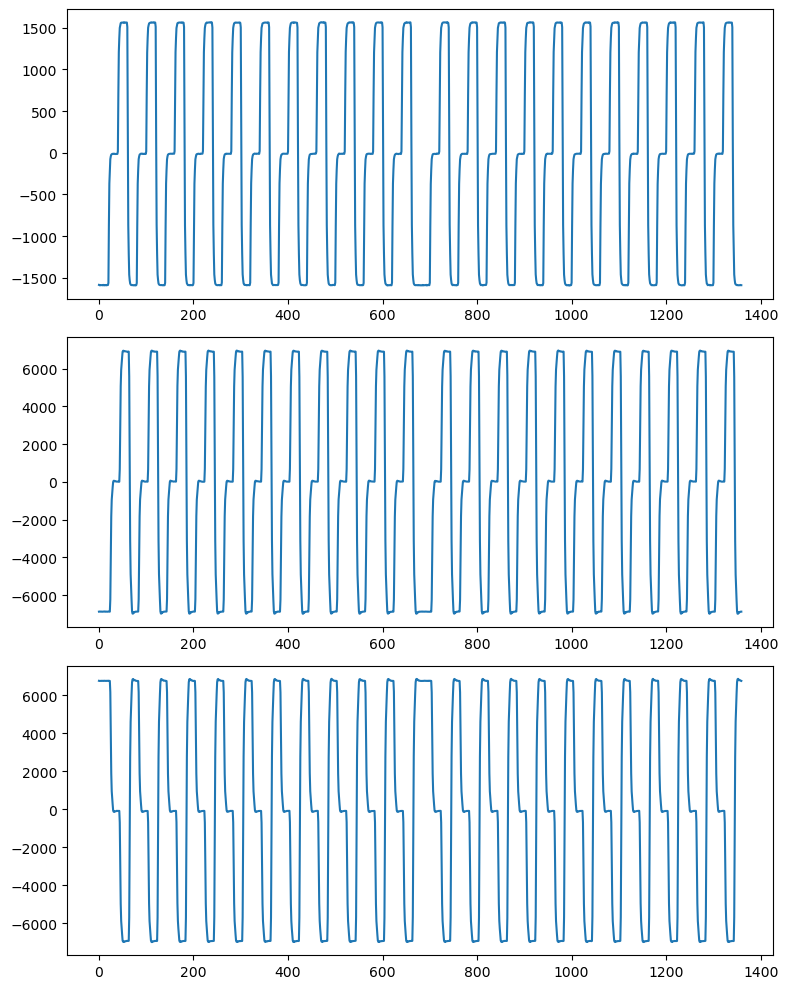

In [11]:
# Plotting the dumps
fig1, ax1 = plt.subplots(3, 1, figsize=(8, 10))
col = 2
ax1[0].plot(dumpref[col, :])
ax1[1].plot(dump1[col, :])
col = 0
ax1[2].plot(dump2[col, :])
fig1.tight_layout()
plt.savefig(os.path.join(path, 'SQUIDsimGain1.png'), dpi=300, bbox_inches='tight')


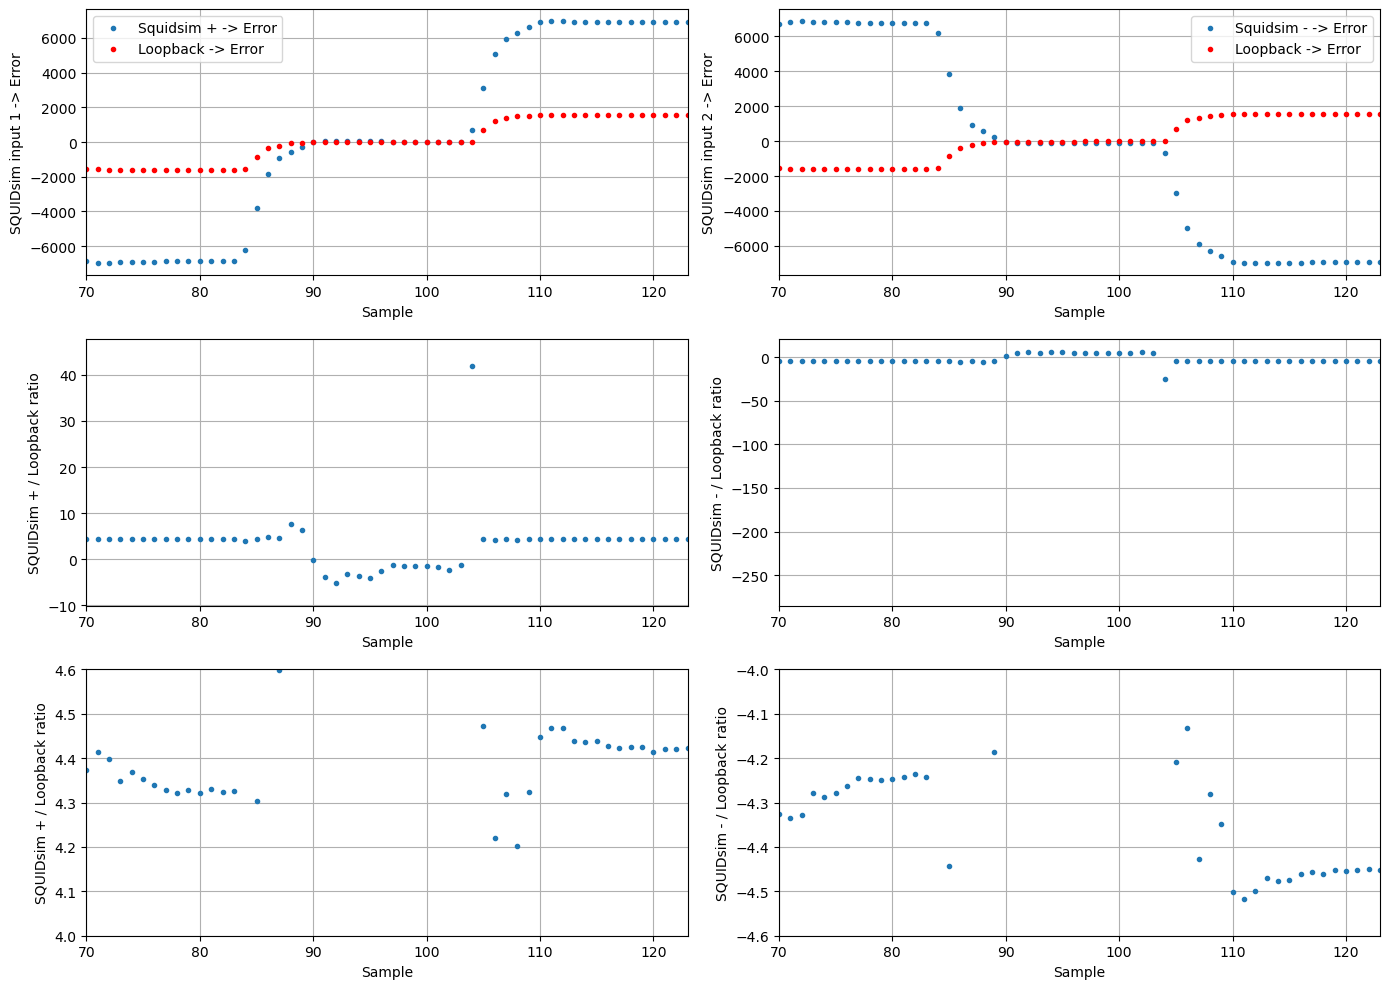

In [71]:
# Plotting the gain
fig2 = plt.figure(figsize=(14, 10))
shift = 4
dumpref_shift = np.roll(dumpref, shift)

ax10 = fig2.add_subplot(3, 2, 1)
ax11 = fig2.add_subplot(3, 2, 3)
ax12 = fig2.add_subplot(3, 2, 5)
ax20 = fig2.add_subplot(3, 2, 2)
ax21 = fig2.add_subplot(3, 2, 4)
ax22 = fig2.add_subplot(3, 2, 6)
xmin, xmax = 70, 123
ymin, ymax = 4.0, 4.6

col = 2
ax10.plot(dump1[col, :], '.', label='Squidsim + -> Error')
ax10.plot(dumpref_shift[col, :], '.r', label='Loopback -> Error')
ax10.set_xlabel('Sample')
ax10.set_ylabel('SQUIDsim input 1 -> Error')
ax10.set_xlim(xmin, xmax)
ax10.grid()
ax10.legend()
ax11.plot(dump1[col, :] / dumpref_shift[col, :], '.')
ax11.set_xlabel('Sample')
ax11.set_ylabel('SQUIDsim + / Loopback ratio')
ax11.set_xlim(xmin, xmax)
ax11.grid()
ax12.plot(dump1[col, :] / dumpref_shift[col, :], '.')
ax12.set_xlabel('Sample')
ax12.set_ylabel('SQUIDsim + / Loopback ratio')
ax12.set_xlim(xmin, xmax)
ax12.set_ylim(ymin, ymax)
ax12.grid()
col = 0
ax20.plot(dump2[col, :], '.', label='Squidsim - -> Error')
ax20.plot(dumpref_shift[col, :], '.r', label='Loopback -> Error')
ax20.set_xlabel('Sample')
ax20.set_ylabel('SQUIDsim input 2 -> Error')
ax20.set_xlim(xmin, xmax)
ax20.grid()
ax20.legend()
ax21.plot(dump2[col, :] / dumpref_shift[col, :], '.')
ax21.set_xlabel('Sample')
ax21.set_ylabel('SQUIDsim - / Loopback ratio')
ax21.set_xlim(xmin, xmax)
ax21.grid()
ax22.plot(dump2[col, :] / dumpref_shift[col, :], '.')
ax22.set_xlabel('Sample')
ax22.set_ylabel('SQUIDsim - / Loopback ratio')
ax22.set_xlim(xmin, xmax)
ax22.set_ylim(-ymax, -ymin)
ax22.grid()
fig2.tight_layout()
plt.savefig(os.path.join(path, 'SQUIDsimGain2.png'), dpi=300, bbox_inches='tight')


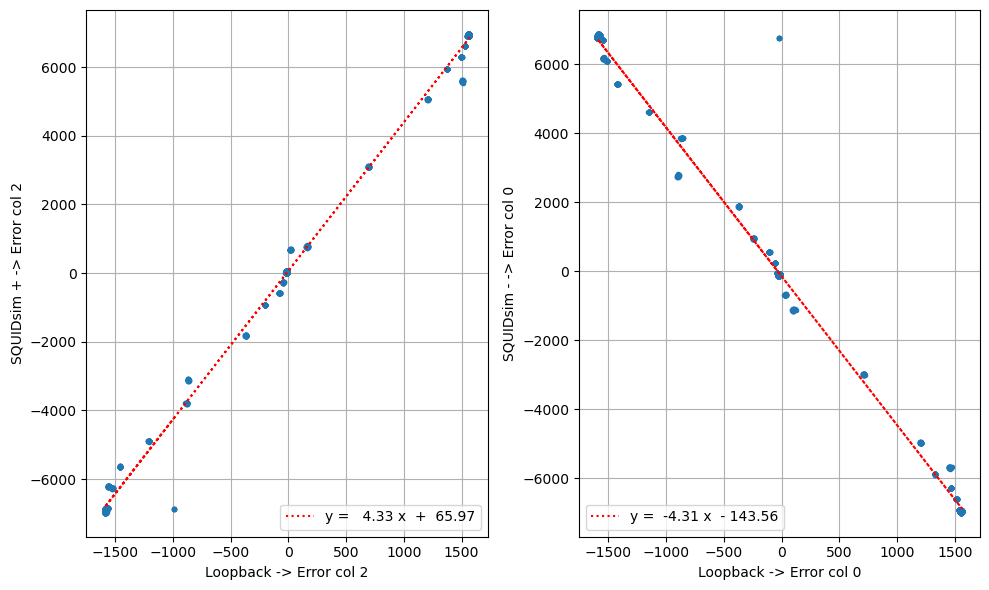

In [70]:

# Plotting the gain
fig3 = plt.figure(figsize=(10, 6))
shift = 4
dumpref_shift = np.roll(dumpref, shift)

ax1 = fig3.add_subplot(1, 2, 1)
ax2 = fig3.add_subplot(1, 2, 2)

col = 2
coeffs1 = np.polyfit(dumpref_shift[col, :], dump1[col, :], deg=1)  # deg=1 => droite
a1, b1 = coeffs1
ax1.plot(dumpref_shift[col, :], dump1[col, :], '.')
sig1 = ' + '
if b1 < 0:
    sig1 = ' - '
lbl1 = 'y = {0:6.2f} x '.format(a1) + sig1 + '{0:6.2f}'.format(np.abs(b1))
ax1.plot(dumpref_shift[col, :], a1 * dumpref_shift[col, :] + b1, ':r', label=lbl1)
ax1.grid()
ax1.legend(loc='lower right')
ax1.set_xlabel('Loopback -> Error col 2')
ax1.set_ylabel('SQUIDsim + -> Error col 2')

col = 0
coeffs2 = np.polyfit(dumpref_shift[col, :], dump2[col, :], deg=1)  # deg=1 => droite
a2, b2 = coeffs2
ax2.plot(dumpref_shift[col, :], dump2[col, :], '.')
sig2 = ' + '
if b2 < 0:
    sig2 = ' - '
lbl2 = 'y = {0:6.2f} x '.format(a2) + sig2 + '{0:6.2f}'.format(np.abs(b2))
ax2.plot(dumpref_shift[col, :], a2 * dumpref_shift[col, :] + b2, ':r', label=lbl2)
ax2.grid()
ax2.legend(loc='lower left')
ax2.set_xlabel('Loopback -> Error col 0')
ax2.set_ylabel('SQUIDsim - -> Error col 0')
fig3.tight_layout()
plt.savefig(os.path.join(path, 'SQUIDsimGain3.png'), dpi=300, bbox_inches='tight')
